# Using `mlcolvar` with graph neural networks
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_gnn_based_cvs.ipynb)

Prerequisites:
- Most of the workings of the library are the same using standard feed-forward-nn-based machine-learning CVs or GNN-based ones.
Thus, it is recommended to first go through the basic tutorials for the standard scenario before moving to this tutorial.

Reference papers: 
- _Zhang, Bonati, Trizio, Zhang, Kang, Hou, and Parrinello, [JCTC](https://doi.org/10.1021/acs.jctc.4c01197) (2025), [ArXiv](https://arxiv.org/abs/2409.07339)_

Author: Enrico Trizio, Kai Zhu

**NOTE**: For a more advanced usage of GNN models, allowing for better performance and lower computational costs in some scenarios, also check the tutorial on truncated GNNs.

In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess

    subprocess.run(
        "wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh",
        shell=True,
        check=True,
    )
    subprocess.run(
        "bash colab_setup.sh TUTORIAL",
        shell=True,
        check=True,
    )

    print("Done!")


## Overview

Descriptor-based collective variables typically use a feed-forward neural network acting on precomputed distances, angles, coordination numbers, or other molecular descriptors.

Graph-based collective variables instead operate directly on atomic coordinates. Atoms are represented as graph nodes, while edges connect neighboring atoms within a radial cutoff. This removes the need to manually define a fixed descriptor set, although graph construction and message passing are generally more computationally demanding.

In `mlcolvar`, the graph backbone is initialized independently and then passed to the selected CV method. This makes it possible to use different graph architectures without changing the rest of the training workflow.


## Load the graph dataset

The example uses configurations from the two metastable states of alanine dipeptide. Graph connectivity is determined from the atomic coordinates using a radial cutoff.

The existing `create_dataset_from_trajectories` utility constructs the graph entries and stores shared graph parameters, such as the cutoff and atomic-number table, in `dataset.metadata`.


In [2]:
from mlcolvar.data import DictModule
from mlcolvar.io import create_dataset_from_trajectories

load_args = [
    {"start": 0, "stop": 10000, "stride": 5},
    {"start": 0, "stop": 10000, "stride": 5},
]

dataset = create_dataset_from_trajectories(
    trajectories=[
        "alad_A.trr",
        "alad_B.trr",
    ],
    topologies="alad.gro",
    folder="data/alanine_gnn",
    cutoff=10.0,
    system_selection="all and not type H",
    show_progress=False,
    load_args=load_args,
    lengths_conversion=10.0,
)

print("Dataset information:")
print(dataset)

datamodule = DictModule(
    dataset=dataset,
    lengths=[0.8, 0.2],
)

print("\nDatamodule information:")
print(datamodule)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kzhu-iit.local/data/mlcolvar-aot-compile/mlcolvar-aot-compile/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


Dataset information:
DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [6, 7, 8],
		      "cutoff": 10.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
		      "system_atoms_names": [ACE1-CH3, ACE1-C, ACE1-O, ALA2-N, ALA2-CA, ALA2-CB, ALA2-C, ALA2-O, NME3-N, NME3-C],
		      "is_truncated_graph": False,
		      "data_type": graphs } )

Datamodule information:
DictModule(dataset -> DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [6, 7, 8],
		      "cutoff": 10.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
		      "system_atoms_names": [ACE1-CH3, ACE1-C, ACE1-O, ALA2-N, ALA2-CA, ALA2-CB, ALA2-C, ALA2-O, NME3-N, NME3-C],
		      "is_truncated_graph": False,
		      "data_type": graphs } ),
	     train_loader -> DictLoader(length=0.8, batch_size=4000, shuffle=True),
	     valid_loader -> DictLoader(length=0.2,

In [3]:
print("Example graph entry:")
print(dataset["data_list"][0])

print("\nDataset metadata:")
print(dataset.metadata)

assert dataset.metadata["data_type"] == "graphs"
assert dataset.metadata["cutoff"] == 10.0


Example graph entry:
Data(edge_index=[2, 90], shifts=[90, 3], unit_shifts=[90, 3], positions=[10, 3], cell=[3, 3], node_attrs=[10, 3], graph_labels=[1, 1], n_system=[1, 1], n_env=[1, 1], system_masks=[10, 1], weight=1.0, subsystem_masks=[10, 1], edge_masks_lr=[90, 1], system_names_idx=[10])

Dataset metadata:
{'atomic_numbers': [6, 7, 8], 'cutoff': 10.0, 'buffer': 0.0, 'long_range_cutoff': -1.0, 'system_idx': tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), 'system_atoms_names': [ACE1-CH3, ACE1-C, ACE1-O, ALA2-N, ALA2-CA, ALA2-CB, ALA2-C, ALA2-O, NME3-N, NME3-C], 'is_truncated_graph': False, 'data_type': 'graphs'}


## Choose the GNN architecture

This tutorial supports three graph backbones.

### SchNet

SchNet uses scalar node features and distance-based continuous-filter convolutions. Its hidden representations are rotationally invariant.

### PaiNN

PaiNN augments scalar node features with equivariant vector features. The vector channels rotate with the molecular geometry, allowing the model to retain directional information while producing a rotationally invariant scalar CV after pooling.

### GVP

The Geometric Vector Perceptron (GVP) represents each node using separate scalar and vector channels. GVP layers transform and mix these channels while preserving rotational equivariance. The vector-gating mechanism allows geometric information to modulate scalar and vector features efficiently.

All three models implement the graph-model interface expected by the CV classes. Therefore, changing the backbone only requires changing `gnn_architecture` below; the `DeepTDA`, training, evaluation, and export sections remain unchanged.


In [4]:
from mlcolvar.core.nn.graph.schnet import SchNetModel
from mlcolvar.core.nn.graph.painn import PaiNNModel
from mlcolvar.core.nn.graph.gvp import GVPModel


# Select "schnet", "painn", or "gvp".
gnn_architecture = "painn"


if gnn_architecture == "schnet":
    gnn_model = SchNetModel(
        n_out=1,
        dataset_for_initialization=dataset,
        pooling_operation="mean",
        n_bases=16,
        n_layers=2,
        n_filters=16,
        n_hidden_channels=16,
        w_out_after_pool=True,
        aggr="mean",
    )

elif gnn_architecture == "painn":
    gnn_model = PaiNNModel(
        n_out=1,
        dataset_for_initialization=dataset,
        pooling_operation="mean",
        n_bases=16,
        n_layers=2,
        n_hidden_channels=16,
        w_out_after_pool=True,
        aggr="sum",
    )

elif gnn_architecture == "gvp":
    gnn_model = GVPModel(
        n_out=1,
        dataset_for_initialization=dataset,
        pooling_operation="mean",
        n_bases=16,
        n_polynomials=6,
        n_layers=2,
        n_messages=2,
        n_feedforwards=2,
        n_scalars_node=16,
        n_vectors_node=8,
        n_scalars_edge=16,
        drop_rate=0.0,
        activation="SiLU",
        basis_type="bessel",
        smooth=False,
    )

else:
    raise ValueError(
        "gnn_architecture must be 'schnet', 'painn', or 'gvp'."
    )


n_parameters = sum(
    parameter.numel()
    for parameter in gnn_model.parameters()
    if parameter.requires_grad
)

print("Selected architecture:", gnn_architecture)
print("Trainable parameters:", n_parameters)
print(gnn_model)


Selected architecture: painn
Trainable parameters: 7713
PaiNNModel(
  (_radial_embedding): RadialEmbeddingBlock(
    (bessel_fn): GAUSSIANBASIS [ 16 󰯰 | 10.000000 󰳁 ]
  )
  (W_v): Linear(in_features=3, out_features=16, bias=False)
  (layers_message): ModuleList(
    (0-1): 2 x MessagePassingPaiNN()
  )
  (layers_update): ModuleList(
    (0-1): 2 x UpdatePaiNN(
      (lin1): Linear(in_features=32, out_features=16, bias=True)
      (lin2): Linear(in_features=16, out_features=48, bias=True)
      (linu): Linear(in_features=16, out_features=16, bias=False)
      (linv): Linear(in_features=16, out_features=16, bias=False)
      (silu): SiLU()
    )
  )
  (W_out): ModuleList(
    (0): Linear(in_features=16, out_features=8, bias=True)
    (1): SiLU()
    (2): Linear(in_features=8, out_features=1, bias=True)
  )
)


The graph parameters should normally be inferred through `dataset_for_initialization`. This keeps the dataset, model, and graph built during deployment consistent.

The parameters can also be supplied manually by setting `dataset_for_initialization=None` and passing values such as `cutoff`, `atomic_numbers`, and `buffer`, but this is more error-prone.


In [5]:
# Verify that the selected backbone accepts the graph format.
graph_inputs = dataset.get_graph_inputs()

with __import__("torch").no_grad():
    backbone_output = gnn_model(graph_inputs)

print("Backbone output shape:", backbone_output.shape)

assert backbone_output.ndim == 2
assert backbone_output.shape[0] == len(dataset)
assert backbone_output.shape[1] == 1


Backbone output shape: torch.Size([4000, 1])


## Initialize the CV

The initialized graph model can be passed directly to any compatible CV method. Here, it is used as the model block of a two-state `DeepTDA` CV.


In [6]:
import torch

from mlcolvar.cvs import DeepTDA


options = {
    "optimizer": {
        "lr": 1e-3,
    },
    "lr_scheduler": {
        "scheduler": torch.optim.lr_scheduler.ExponentialLR,
        "gamma": 0.9999,
    },
}

model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7, 7],
    target_sigmas=[0.2, 0.2],
    model=gnn_model,
    options=options,
)

model


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


DeepTDA(
  (loss_fn): TDALoss()
  (nn): PaiNNModel(
    (_radial_embedding): RadialEmbeddingBlock(
      (bessel_fn): GAUSSIANBASIS [ 16 󰯰 | 10.000000 󰳁 ]
    )
    (W_v): Linear(in_features=3, out_features=16, bias=False)
    (layers_message): ModuleList(
      (0-1): 2 x MessagePassingPaiNN()
    )
    (layers_update): ModuleList(
      (0-1): 2 x UpdatePaiNN(
        (lin1): Linear(in_features=32, out_features=16, bias=True)
        (lin2): Linear(in_features=16, out_features=48, bias=True)
        (linu): Linear(in_features=16, out_features=16, bias=False)
        (linv): Linear(in_features=16, out_features=16, bias=False)
        (silu): SiLU()
      )
    )
    (W_out): ModuleList(
      (0): Linear(in_features=16, out_features=8, bias=True)
      (1): SiLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
    )
  )
)

## Train the CV

Training follows the standard Lightning workflow. Model-summary generation is disabled because Lightning may otherwise try to expand graph fields into keyword arguments instead of passing the graph batch as a single input.


In [ ]:
from lightning import Trainer

from mlcolvar.utils.trainer import MetricsCallback


metrics = MetricsCallback()

trainer = Trainer(
    callbacks=[metrics],
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    max_epochs=5,
)

trainer.fit(model, datamodule)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking DataLoader 0:   0%|          | 0/1 [00:00<?, ?it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  2.47it/s]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  2.47it/s]


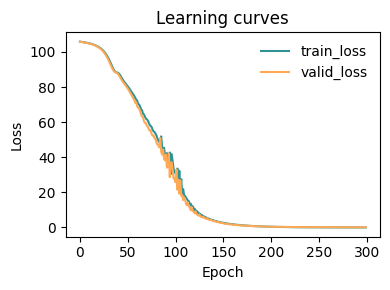

In [8]:
import matplotlib.pyplot as plt

from mlcolvar.utils.plot import plot_metrics


fig, ax = plt.subplots(figsize=(4, 3))

plot_metrics(
    metrics.metrics,
    keys=["train_loss", "valid_loss"],
    colors=["fessa1", "fessa5"],
    yscale="linear",
    ax=ax,
)

fig.tight_layout()


## Evaluate the model

`DictDataset.get_graph_inputs` and `DictModule.get_graph_inputs` collect graph entries into the batch format expected by the GNN.


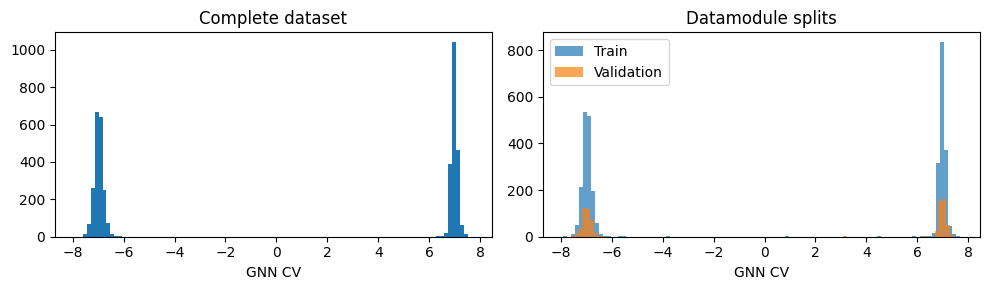

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

with torch.no_grad():
    dataset_output = model(
        dataset.get_graph_inputs()
    ).detach().squeeze()

    train_output = model(
        datamodule.get_graph_inputs("train")
    ).detach().squeeze()

    valid_output = model(
        datamodule.get_graph_inputs("valid")
    ).detach().squeeze()

axes[0].hist(
    dataset_output.cpu(),
    bins=100,
)
axes[0].set_title("Complete dataset")
axes[0].set_xlabel("GNN CV")

axes[1].hist(
    train_output.cpu(),
    bins=100,
    alpha=0.7,
    label="Train",
)
axes[1].hist(
    valid_output.cpu(),
    bins=100,
    alpha=0.7,
    label="Validation",
)
axes[1].set_title("Datamodule splits")
axes[1].set_xlabel("GNN CV")
axes[1].legend()

fig.tight_layout()


## Export to TorchScript

The trained CV can be traced using representative graph inputs. The exported model should reproduce the original model output on the same graph batch.


In [10]:
model.eval()

traced_model = model.to_torchscript(
    "gnn_model.pt",
    method="trace",
)

graph_inputs = dataset.get_graph_inputs()

with torch.no_grad():
    reference_output = model(graph_inputs)
    traced_output = traced_model(graph_inputs)

torch.testing.assert_close(
    traced_output,
    reference_output,
)

print(
    f"{gnn_architecture} model exported successfully."
)

/home/kzhu-iit.local/data/mlcolvar-aot-compile/mlcolvar-aot-compile/mlcolvar/data/datamodule.py:341: UserWarning: Length of split at index 1 is 0. This might result in an empty dataset.
  warnings.warn(


painn model exported successfully.


### Accelerate GNN inference with AOT compilation

For GNN-based CVs, the frozen model can be accelerated for inference using PyTorch AOT compilation.

In [11]:
from mlcolvar.utils.export import export

# Export the GNN model using a representative graph input.
export(
    model,
    example_inputs=dataset[0],
    file_name="gnn_model.pt2",
    run_check=False,
)

'gnn_model.pt2'